# Break-even frontier

This retailer returns 63.5% of orders — the global high-water mark for fashion. US brands run far lower, so the useful question is not "does $2 coverage work here" but **at what return rate and return cost does it work at all**.

Prevalence is moved with a logit offset, which shifts the base rate while preserving the model's ranking. Because the counterfactual population no longer matches the observed labels, cost here is driven by the shifted **model probability** rather than the measured outcome.

Amounts are shown in dollars; the source retailer is euro-denominated and figures are treated 1:1, with no FX applied.

**Config.** The same demand assumptions as notebook 08, plus the industry benchmark bands drawn on the chart. Prices sweep $0.50–$8.00; return rates sweep 5%–70%.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import expit, logit
from src.data import INTERIM, ROOT

FIGURES = ROOT / "figures"
PRICE_SENSITIVITY, ADVERSE_SELECTION, MORAL_HAZARD, TARGET_TAKE = 0.45, 2.0, 0.10, 0.20
PRICES = np.round(np.arange(0.50, 8.01, 0.10), 2)
COSTS = [5.0, 8.0, 10.0]
BENCHMARKS = [("electronics\n8-15%", 11.5), ("apparel\n20%", 20.0), ("US fashion\n25-30%", 27.5)]

p = pd.read_parquet(INTERIM / "predictions.parquet")
r_obs = np.clip(p.pred.values, 1e-6, 1 - 1e-6)
len(p), round(float(r_obs.mean()), 4)

(113966, 0.6321)

## Prevalence shift

**Prevalence shift by logit offset.** Convert probabilities to log-odds, add a constant, convert back. Adding a constant in log-odds space is monotone, so the model's *ranking* is untouched and only the base rate moves. `brentq` finds the offset hitting the target mean. This answers 'what if this same model ran at a merchant with a 20% return rate' without resampling, which would change the population mix as well.

In [2]:
def shift_to(target, r=r_obs):
    """Logit offset moving mean predicted risk to ``target`` while preserving ranking."""
    d = brentq(lambda delta: expit(logit(r) + delta).mean() - target, -20, 20)
    return expit(logit(r) + d)

pd.DataFrame([{"target": t, "achieved": shift_to(t).mean()} for t in [0.10, 0.20, 0.30, 0.6321]]).round(4)

,target,achieved
0,0.1000,0.1000
1,0.2000,0.2000
2,0.3000,0.3000
3,0.6321,0.6321


## Profit

**Profit machinery.** Same structure as notebook 08, but the intercept is re-solved for each shifted population, since a different base rate implies a different demand curve.

In [3]:
def curve_for(r):
    r_mean = r.mean()
    intercept = brentq(lambda a: expit(a - PRICE_SENSITIVITY * 2.0 + ADVERSE_SELECTION * (r - r_mean)).mean() - TARGET_TAKE, -20, 20)
    r_eff = r + MORAL_HAZARD * (1 - r)
    def profit(price):
        t = expit(intercept - PRICE_SENSITIVITY * price + ADVERSE_SELECTION * (r - r_mean))
        return float(np.mean(t * (price - cost_now[0] * r_eff)))
    return profit

cost_now = [8.0]
def profit_at(price, cost, r):
    cost_now[0] = cost
    return curve_for(r)(price)

def best_profit(cost, r):
    cost_now[0] = cost
    f = curve_for(r)
    vals = [f(pr) for pr in PRICES]
    i = int(np.argmax(vals))
    return float(PRICES[i]), vals[i]

## Frontier

**Two resolutions.** A fine grid draws a smooth curve; a 5% step table gives readable numbers. Both report profit at $2 and the best achievable price.

In [4]:
RATES_FINE = np.round(np.arange(0.05, 0.71, 0.01), 2)
grid = pd.DataFrame([{"rate": rate, "cost": cost, "profit_at_2": profit_at(2.00, cost, shift_to(rate))}
                     for rate in RATES_FINE for cost in COSTS])

RATES_STEP = np.round(np.arange(0.10, 0.71, 0.05), 2)
table = []
for rate in RATES_STEP:
    r = shift_to(rate)
    row = {"return_rate": rate}
    for cost in COSTS:
        bp, bprof = best_profit(cost, r)
        row[f"profit@$2_cost{int(cost)}"] = round(profit_at(2.00, cost, r), 4)
        row[f"best_price_cost{int(cost)}"] = bp
        row[f"best_profit_cost{int(cost)}"] = round(bprof, 4)
    table.append(row)
step_table = pd.DataFrame(table)
step_table[["return_rate"] + [c for c in step_table.columns if "profit@$2" in c]].round(4)

,return_rate,profit@$2_cost5,profit@$2_cost8,profit@$2_cost10
0,0.10,0.1544,0.0070,-0.0912
1,0.15,0.0745,-0.1208,-0.2510
2,0.20,0.0003,-0.2394,-0.3993
3,0.25,-0.0659,-0.3455,-0.5318
4,0.30,-0.1241,-0.4386,-0.6482
5,0.35,-0.1751,-0.5201,-0.7501
6,0.40,-0.2199,-0.5918,-0.8397
7,0.45,-0.2597,-0.6555,-0.9194
8,0.50,-0.2956,-0.7129,-0.9911
9,0.55,-0.3284,-0.7654,-1.0567


**Root-find the crossing.** The return rate at which $2 coverage profit hits exactly zero. Below that rate the product makes money; above it, it does not.

In [5]:
def break_even_rate(cost):
    f = lambda rate: profit_at(2.00, cost, shift_to(rate))
    lo, hi = RATES_FINE[0], RATES_FINE[-1]
    if f(lo) < 0 or f(hi) > 0:
        return np.nan
    return float(brentq(f, lo, hi))

be = pd.DataFrame([{"return_cost": c, "break_even_rate_at_$2": break_even_rate(c)} for c in COSTS])
be.round(4)

,return_cost,break_even_rate_at_$2
0,5.0,0.2002
1,8.0,0.1027
2,10.0,0.0719


## Figure

**The frontier chart.** Break-even points are marked and labelled directly, with industry benchmark bands behind them, so the reader can locate their own merchant on the curve.

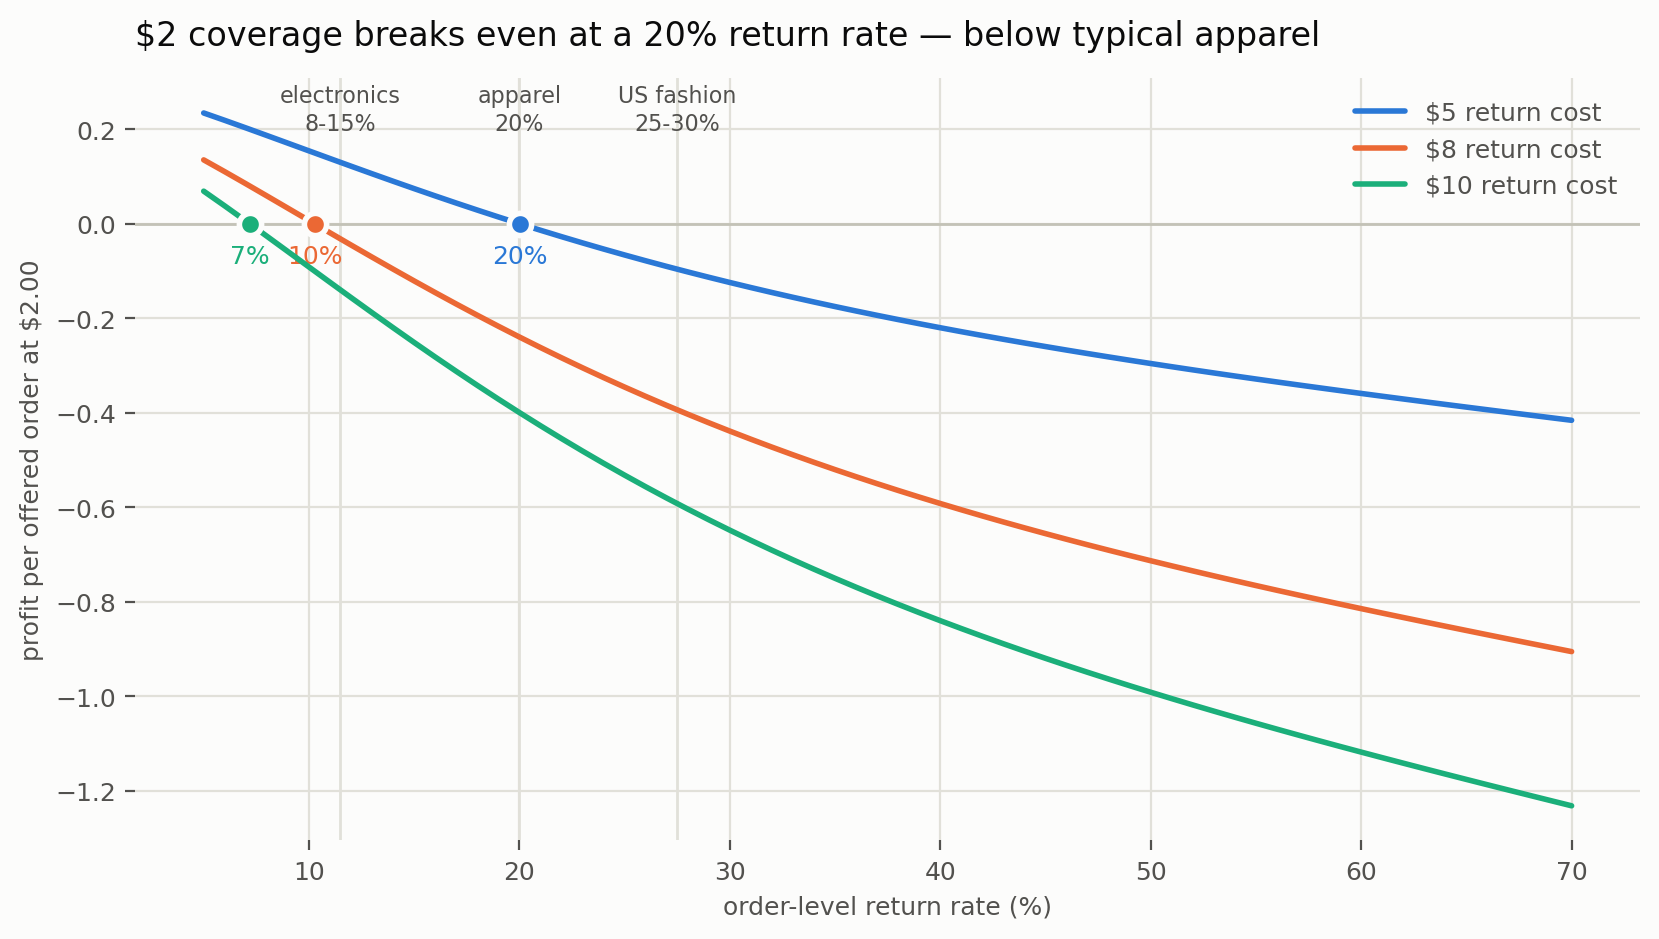

In [6]:
SURFACE, GRID, INK, MUTED, BASE = "#fcfcfb", "#e1e0d9", "#0b0b0b", "#52514e", "#c3c2b7"
SERIES = {5.0: "#2a78d6", 8.0: "#eb6834", 10.0: "#1baf7a"}

fig, ax = plt.subplots(figsize=(8.4, 4.8), dpi=200)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
for c, colour in SERIES.items():
    d = grid[grid.cost == c]
    ax.plot(d.rate * 100, d.profit_at_2, color=colour, linewidth=2,
            solid_capstyle="round", zorder=4, label=f"${c:.0f} return cost")
ax.axhline(0, color=BASE, linewidth=1, zorder=2)
top = ax.get_ylim()[1]
for label, x in BENCHMARKS:
    ax.axvline(x, color=GRID, linewidth=1, zorder=1)
    ax.annotate(label, (x, top), xytext=(0, -2), textcoords="offset points",
                color=MUTED, fontsize=8, ha="center", va="top", linespacing=1.3)
for c, colour in SERIES.items():
    b = be.loc[be.return_cost == c, "break_even_rate_at_$2"].iloc[0]
    if not np.isnan(b):
        ax.plot([b * 100], [0], marker="o", markersize=8, color=colour,
                markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
        ax.annotate(f"{b*100:.0f}%", (b * 100, 0), xytext=(0, -14), textcoords="offset points",
                    color=colour, fontsize=9, ha="center", fontweight="medium")
ax.grid(True, color=GRID, linewidth=0.8, linestyle="-", zorder=0)
ax.set_axisbelow(True)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("order-level return rate (%)", color=MUTED, fontsize=9)
ax.set_ylabel("profit per offered order at $2.00", color=MUTED, fontsize=9)
ax.set_title("$2 coverage breaks even at a 20% return rate \u2014 below typical apparel",
             color=INK, fontsize=12, pad=12, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(loc="upper right", frameon=False, fontsize=9, labelcolor=MUTED)
fig.tight_layout()
FIGURES.mkdir(exist_ok=True)
fig.savefig(FIGURES / "breakeven_frontier.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Save

**Persist the frontier.** Both the break-even rates and the 5%-step table are saved, so the memo can quote them without re-running an expensive sweep.

In [7]:
out = {"break_even": be.to_dict(orient="records"),
       "step_table": step_table.to_dict(orient="records"),
       "assumptions": {"price_sensitivity": PRICE_SENSITIVITY, "adverse_selection": ADVERSE_SELECTION,
                       "moral_hazard": MORAL_HAZARD, "target_take_at_2": TARGET_TAKE}}
(INTERIM / "frontier.json").write_text(json.dumps(out, indent=2))
step_table.to_csv(INTERIM / "frontier_steps.csv", index=False)
be.round(4)

,return_cost,break_even_rate_at_$2
0,5.0,0.2002
1,8.0,0.1027
2,10.0,0.0719
